In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from empiricaldist import Pmf, Cdf
from scipy.stats import norm
from scipy.stats import weibull_min
import scipy

In [ ]:
# functions

def normalize(joint):
    """Normalize the joint distribution."""
    prob_data = joint.to_numpy().sum()
    joint /= prob_data
    return prob_data

def make_joint(pmf1, pmf2):
    """Make a joint distribution from two PMFs."""
    X, Y = np.meshgrid(pmf1, pmf2)
    return pd.DataFrame(X * Y, columns=pmf1.qs, index=pmf2.qs)

def make_uniform(qs, name=None, **options):
    """Make a uniform PMF."""
    pmf = Pmf(1.0, qs, **options)
    pmf.normalize()
    if name:
        pmf.index.name = name
    return pmf

def weibull_dist(lam, k):
    return weibull_min(k, scale=lam)

def update_weibull(prior, data):
    """Update the joint distribution based on the data."""
    lam_mesh, k_mesh, data_mesh = np.meshgrid(prior.columns, prior.index, data)
    
    densities = weibull_dist(lam_mesh, k_mesh).pdf(data_mesh)
    likelihood = densities.prod(axis=2)

    posterior = prior * likelihood
    normalize(posterior)

    return posterior

In [3]:
df = pd.read_csv('lamps.csv')

In [4]:
pmf_bulb = Pmf(df['f'].to_numpy(), df['h'])


In [5]:
pmf_bulb.normalize()

np.int64(50)

In [6]:
lams = np.linspace(1000, 2000, num=51)
prior_lam = make_uniform(lams, name='lambda')

In [7]:
ks = np.linspace(1, 10, num=51)
prior_k = make_uniform(ks, name='k')

In [8]:
prior_bulb = make_joint(prior_lam, prior_k)

In [9]:
data_bulb = np.repeat(df['h'], df['f'])
len(data_bulb)

50

In [10]:
posterior_bulb = update_weibull(prior_bulb, data_bulb)

/home/usgs_luisgarc/miniforge3/envs/learning/lib/python3.14/site-packages/scipy/stats/_continuous_distns.py:2750: RuntimeWarning: overflow encountered in power
  return c*pow(x, c-1)*np.exp(-pow(x, c))
/home/usgs_luisgarc/miniforge3/envs/learning/lib/python3.14/site-packages/scipy/stats/_continuous_distns.py:2750: RuntimeWarning: invalid value encountered in multiply
  return c*pow(x, c-1)*np.exp(-pow(x, c))


In [11]:
lam_mesh, k_mesh = np.meshgrid(prior_bulb.columns, prior_bulb.index)

means = weibull_dist(lam_mesh, k_mesh).mean()
means.shape

(51, 51)

In [12]:
prod = means * posterior_bulb

prod.to_numpy().sum()

np.float64(nan)

In [13]:
def joint_weibull_mean(joint):
    '''Compute the mean of a Weibull distribution based on a joint distribution of parameters.'''
    lam_mesh, k_mesh = np.meshgrid(joint.columns, joint.index)
    means = weibull_dist(lam_mesh, k_mesh).mean()
    return (means * joint).to_numpy().sum()

In [14]:
joint_weibull_mean(posterior_bulb)

np.float64(nan)

In [15]:
joint_weibull_mean(prior_bulb)

np.float64(5.497798590076293)

#### Exercise

In [16]:
def gamma_dist(k, theta):
    """Makes a gamma object.
    
    k: shape parameter
    theta: scale parameter
    
    returns: gamma object
    """
    return scipy.stats.gamma(k, scale=theta)

In [17]:
weather = pd.read_csv('2203951.csv')
weather.head()

,STATION,NAME,DATE,AWND,PRCP,TMAX,TMIN,WT01,WT03,WT08
0,USW00024233,"SEATTLE TACOMA AIRPORT, WA US",2020-05-01,4.47,0.00,66,43,NaN,NaN,NaN
1,USW00024233,"SEATTLE TACOMA AIRPORT, WA US",2020-05-02,9.40,0.24,58,47,1.0,NaN,NaN
2,USW00024233,"SEATTLE TACOMA AIRPORT, WA US",2020-05-03,11.63,0.06,57,44,1.0,NaN,NaN
3,USW00024233,"SEATTLE TACOMA AIRPORT, WA US",2020-05-04,4.47,0.00,65,39,NaN,NaN,NaN
4,USW00024233,"SEATTLE TACOMA AIRPORT, WA US",2020-05-05,7.83,0.00,71,49,NaN,NaN,NaN


In [18]:
rained = weather['PRCP'] > 0
rained.sum()

np.int64(14)

In [19]:
prcp = weather.loc[rained, 'PRCP']
prcp.describe()

count    14.000000
mean      0.222857
std       0.301060
min       0.010000
25%       0.052500
50%       0.110000
75%       0.225000
max       1.140000
Name: PRCP, dtype: float64

Text(0.5, 1.0, 'Distribution of rainfall on days it rained')

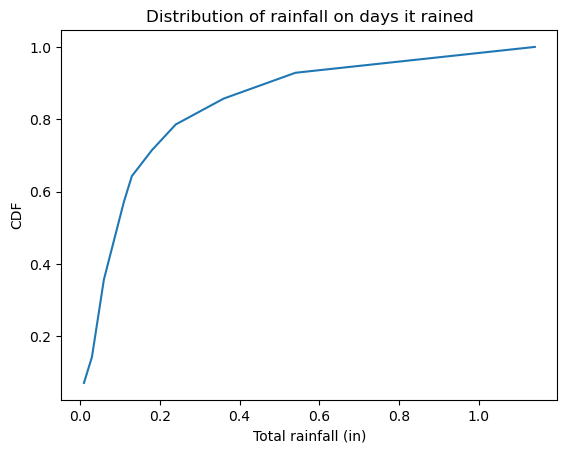

In [20]:
cdf_data = Cdf.from_seq(prcp)
cdf_data.plot()
plt.xlabel('Total rainfall (in)')
plt.ylabel('CDF')
plt.title('Distribution of rainfall on days it rained')

In [25]:
k_est, _, theta_est = scipy.stats.gamma.fit(prcp, floc=0)
k_est, theta_est

(0.8898876017525283, np.float64(0.25043291132301665))

In [26]:
ks = np.linspace(0.01, 2, num=51)
prior_k = make_uniform(ks, name='k')

In [27]:
thetas = np.linspace(0.01, 1.5, num=51)
prior_theta = make_uniform(thetas, name='theta')

In [28]:
prior = make_joint(prior_k, prior_theta)

In [29]:
k_mesh, theta_mesh, data_mesh = np.meshgrid(
    prior.columns, prior.index, prcp)

In [30]:
densities = gamma_dist(k_mesh, theta_mesh).pdf(data_mesh) 
densities.shape

(51, 51, 14)

In [31]:
likelihood = densities.prod(axis=2)
likelihood.sum()

np.float64(147970.07763585207)

In [32]:
posterior = prior * likelihood
normalize(posterior)

np.float64(56.889687672376816)

In [33]:
def plot_contour(joint):
    '''plot a joint distribution as a contour plot.'''
    plt.contour(joint.columns, joint.index, joint, cmap='viridis')

Text(0.5, 1.0, 'Posterior distribution, parameters of a gamma distribution')

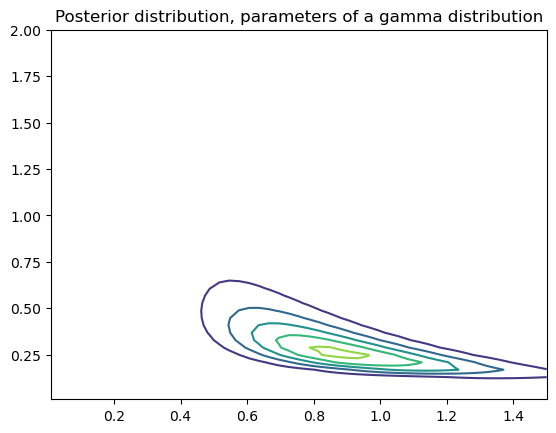

In [34]:
plot_contour(posterior)

plt.title('Posterior distribution, parameters of a gamma distribution')